# BIRLA INSTITUTE OF TECHNOLOGY AND SCIENCE, PILANI
## WORK INTEGRATED LEARNING PROGRAMMES DIVISION
### Deep Reinforcement Learning - Lab Assignment 1
### Part 2: Autonomous Drone Rescue Using Dynamic Programming
---
**Total Marks: 5**

**Submission:** Team # - DP

## Cell 1: Virtual Lab System Information
Prints timestamp, hostname, and platform details for submission.

In [1]:
import datetime
import platform
import socket

print('=' * 60)
print('       VIRTUAL LAB EXECUTION INFORMATION')
print('=' * 60)
print(f'Timestamp      : {datetime.datetime.now()}')
print(f'VM Hostname    : {socket.gethostname()}')
print(f'Platform       : {platform.platform()}')
print(f'Python Version : {platform.python_version()}')
print(f'Machine        : {platform.machine()}')
print('=' * 60)


       VIRTUAL LAB EXECUTION INFORMATION
Timestamp      : 2026-06-06 17:40:34.571299
VM Hostname    : LAPTOP-BAV1OJCU
Platform       : Windows-10-10.0.26200-SP0
Python Version : 3.9.7
Machine        : AMD64


## Cell 2: Import Required Libraries

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import datetime
import platform
import socket

# Save all output files to the DP directory
try:
    OUTPUT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    OUTPUT_DIR = os.getcwd()  # Jupyter: CWD is the notebook's own directory

print('All libraries imported successfully!')
print(f'NumPy version     : {np.__version__}')
print(f'Matplotlib version: {plt.matplotlib.__version__}')


All libraries imported successfully!
NumPy version     : 1.20.3
Matplotlib version: 3.4.3


## Task 1: Environment Configuration
Set group-specific parameters and define the grid layout.

In [3]:
# ============================================================
# CONFIGURATION - Replace G with your actual group number
# ============================================================

G           = 204     # REPLACE WITH YOUR GROUP NUMBER
GRID_SIZE   = 6      # 6x6 grid for ID ending 5-9
MAX_BATTERY = 15     # Maximum battery units (odd student ID)
WIND_PROB   = 0.30   # 30% wind probability for ID ending 5-9
GAMMA       = 0.95   # Discount factor
THETA       = 1e-3   # Convergence threshold
MAX_STEPS   = 75     # Maximum steps per episode (75 for 6x6)

# Grid cell locations
START_POS   = (0, 0)
TARGET_LOCS = [(1, 4), (4, 1), (5, 4)]
CHARGE_LOCS = [(4, 5), (5, 1)]
DANGER_LOCS = [(1, 1), (2, 2), (3, 3), (5, 3)]
BLOCK_LOCS  = [(0, 1), (2, 3), (5, 2)]
WIND_LOCS   = [(2, 1)]
NUM_TARGETS = len(TARGET_LOCS)

print(f'Group Number   : {G}')
print(f'Grid Size      : {GRID_SIZE}x{GRID_SIZE}')
print(f'Max Battery    : {MAX_BATTERY}')
print(f'Wind Prob      : {WIND_PROB*100:.0f}%')
print(f'Gamma          : {GAMMA}')
print(f'Theta          : {THETA}')
print(f'Rescue Targets : {TARGET_LOCS}')
print(f'Charge Stations: {CHARGE_LOCS}')
print(f'Danger Zones   : {DANGER_LOCS}')
print(f'Blocked Cells  : {BLOCK_LOCS}')
print(f'Wind Zones     : {WIND_LOCS}')


Group Number   : 204
Grid Size      : 6x6
Max Battery    : 15
Wind Prob      : 30%
Gamma          : 0.95
Theta          : 0.001
Rescue Targets : [(1, 4), (4, 1), (5, 4)]
Charge Stations: [(4, 5), (5, 1)]
Danger Zones   : [(1, 1), (2, 2), (3, 3), (5, 3)]
Blocked Cells  : [(0, 1), (2, 3), (5, 2)]
Wind Zones     : [(2, 1)]


## Task 1: Grid Visualization
Display the grid layout with all cell types labeled.

In [4]:
# ============================================================
# BUILD AND DISPLAY GRID LAYOUT
# S=Start, F=Free, D=Danger, R=Rescue, C=Charge, W=Wind, X=Block
# ============================================================

def build_grid_display():
    grid = [['F'] * GRID_SIZE for _ in range(GRID_SIZE)]
    grid[START_POS[0]][START_POS[1]] = 'S'
    for (r, c) in TARGET_LOCS : grid[r][c] = 'R'
    for (r, c) in CHARGE_LOCS : grid[r][c] = 'C'
    for (r, c) in DANGER_LOCS : grid[r][c] = 'D'
    for (r, c) in BLOCK_LOCS  : grid[r][c] = 'X'
    for (r, c) in WIND_LOCS   : grid[r][c] = 'W'
    return grid

grid_display = build_grid_display()

print('Grid Layout:')
print('-' * (GRID_SIZE * 4))
for row in grid_display:
    print(' '.join(row))
print('-' * (GRID_SIZE * 4))
print('Legend: S=Start, F=Free, D=Danger,')
print('        R=Rescue, C=Charge, W=Wind, X=Block')


Grid Layout:
------------------------
S X F F F F
F D F F R F
F W D X F F
F F F D F F
F R F F F C
F C X D R F
------------------------
Legend: S=Start, F=Free, D=Danger,
        R=Rescue, C=Charge, W=Wind, X=Block


## Task 2: Drone Rescue MDP Environment
Define the custom environment class modelling the MDP.

**State Space:** `(row, col, battery, t0, t1, ...)`

**Action Space:** UP, DOWN, LEFT, RIGHT, HOVER

**Transition Dynamics:**
- Regular moves consume 1 battery unit
- Wind zones introduce stochastic direction changes
- Blocked cells prevent movement
- Charging stations refill battery
- Rescue targets disappear after being reached

In [5]:
# ============================================================
# DRONE RESCUE ENVIRONMENT CLASS
# Models the MDP with full transition dynamics
# ============================================================

class DroneRescueEnv:
    def __init__(self):
        self.actions = ['UP', 'DOWN', 'LEFT', 'RIGHT', 'HOVER']
        self.action_deltas = {
            'UP'   : (-1,  0),
            'DOWN' : ( 1,  0),
            'LEFT' : ( 0, -1),
            'RIGHT': ( 0,  1),
            'HOVER': ( 0,  0)
        }
        self.wind_directions = ['UP', 'DOWN', 'LEFT', 'RIGHT']

    def reset(self):
        self.pos     = START_POS
        self.battery = MAX_BATTERY
        self.targets = tuple([True] * NUM_TARGETS)
        self.steps   = 0
        return self._get_state()

    def _get_state(self):
        return (self.pos[0], self.pos[1], self.battery) + self.targets

    def _is_valid_cell(self, r, c):
        return (0 <= r < GRID_SIZE and
                0 <= c < GRID_SIZE and
                (r, c) not in BLOCK_LOCS)

    def step(self, action):
        r, c = self.pos
        self.steps += 1
        actual_action = action

        # Wind stochasticity
        if (r, c) in WIND_LOCS and action != 'HOVER':
            if np.random.random() < WIND_PROB:
                actual_action = np.random.choice(self.wind_directions)

        # Compute new position
        dr, dc = self.action_deltas[actual_action]
        nr, nc = r + dr, c + dc

        # Stay if invalid
        if not self._is_valid_cell(nr, nc):
            nr, nc = r, c

        # Battery consumption
        self.battery -= 1
        reward = -1

        # Charging station
        # Hovering: battery +2 (net +1 after -1 consumption), capped at MAX
        # Entering: battery refills to MAX; +5 reward only if battery was genuinely low
        # (prevents farming reward by oscillating from an adjacent full-battery cell)
        actually_moved = (nr, nc) != (r, c)
        if (nr, nc) in CHARGE_LOCS:
            if actual_action == 'HOVER':
                self.battery = min(MAX_BATTERY, self.battery + 2)
            elif actually_moved:
                needed_charge = self.battery < MAX_BATTERY // 2
                self.battery = MAX_BATTERY
                if needed_charge:
                    reward = 5

        # Danger zone
        if (nr, nc) in DANGER_LOCS:
            reward = -10

        # Rescue targets
        targets_list = list(self.targets)
        for idx, t_pos in enumerate(TARGET_LOCS):
            if (nr, nc) == t_pos and targets_list[idx]:
                reward = 20
                targets_list[idx] = False
        self.targets = tuple(targets_list)
        self.pos = (nr, nc)

        # Check termination
        done = False
        if self.battery <= 0:
            reward = -20
            done = True
        elif not any(self.targets):
            done = True
        elif self.steps >= MAX_STEPS:
            done = True

        return self._get_state(), reward, done

    def render(self):
        r, c = self.pos
        print(f'Battery: {self.battery}/{MAX_BATTERY} | '
              f'Targets Remaining: {sum(self.targets)}')
        for row in range(GRID_SIZE):
            line = ''
            for col in range(GRID_SIZE):
                if (row, col) == (r, c):
                    line += 'A '
                elif (row, col) in BLOCK_LOCS:
                    line += 'X '
                elif (row, col) in DANGER_LOCS:
                    line += 'D '
                elif (row, col) in CHARGE_LOCS:
                    line += 'C '
                elif (row, col) in WIND_LOCS:
                    line += 'W '
                else:
                    is_target = False
                    for idx, t_pos in enumerate(TARGET_LOCS):
                        if (row, col) == t_pos and self.targets[idx]:
                            is_target = True
                    line += 'R ' if is_target else 'F '
            print(line)

print('DroneRescueEnv class defined successfully!')
env_test = DroneRescueEnv()
state = env_test.reset()
print(f'Initial State: {state}')
print('Initial Grid:')
env_test.render()


DroneRescueEnv class defined successfully!
Initial State: (0, 0, 15, True, True, True)
Initial Grid:
Battery: 15/15 | Targets Remaining: 3
A X F F F F 
F D F F R F 
F W D X F F 
F F F D F F 
F R F F F C 
F C X D R F 


## Task 2: State Space Enumeration
Enumerate all valid states and calculate total state space size.

**State = (row, col, battery, t0, t1)**

**Total = valid_cells x battery_levels x target_combinations**

In [6]:
# ============================================================
# STATE SPACE ENUMERATION
# Generate all valid (row, col, battery, t0, t1) tuples
# ============================================================

def enumerate_states():
    states = []
    target_combos = []
    for mask in range(2 ** NUM_TARGETS):
        combo = tuple(bool((mask >> i) & 1) for i in range(NUM_TARGETS))
        target_combos.append(combo)

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if (r, c) in BLOCK_LOCS:
                continue
            for b in range(MAX_BATTERY + 1):
                for t_combo in target_combos:
                    states.append((r, c, b) + t_combo)
    return states

all_states = enumerate_states()

valid_cells = GRID_SIZE * GRID_SIZE - len(BLOCK_LOCS)
battery_lvl = MAX_BATTERY + 1
target_comb = 2 ** NUM_TARGETS
total_states = valid_cells * battery_lvl * target_comb

print('State Space Analysis:')
print('-' * 50)
print(f'Grid cells (total)      : {GRID_SIZE * GRID_SIZE}')
print(f'Blocked cells           : {len(BLOCK_LOCS)}')
print(f'Valid cells             : {valid_cells}')
print(f'Battery levels (0-{MAX_BATTERY})   : {battery_lvl}')
print(f'Target combinations (2^{NUM_TARGETS}): {target_comb}')
print(f'Total States            : {valid_cells} x {battery_lvl} x {target_comb} = {total_states}')
print(f'Enumerated States       : {len(all_states)}')
print('-' * 50)
print('Example States:')
print(f'  Initial : {all_states[0]}')
print(f'  Middle  : {all_states[len(all_states)//2]}')
print(f'  Last    : {all_states[-1]}')


State Space Analysis:
--------------------------------------------------
Grid cells (total)      : 36
Blocked cells           : 3
Valid cells             : 33
Battery levels (0-15)   : 16
Target combinations (2^3): 8
Total States            : 33 x 16 x 8 = 4224
Enumerated States       : 4224
--------------------------------------------------
Example States:
  Initial : (0, 0, 0, False, False, False)
  Middle  : (3, 0, 8, False, False, False)
  Last    : (5, 5, 15, True, True, True)


## Task 3: Transition Function
Define P(s'|s,a) and R(s,a,s') for the Bellman equation.

**Bellman Optimality Equation:**

$$V^*(s) = \max_a \sum_{s'} P(s'|s,a)[R(s,a,s') + \gamma V^*(s')]$$

In [7]:
# ============================================================
# TRANSITION FUNCTION
# Returns list of (probability, next_state, reward) tuples
# Models all MDP dynamics including wind stochasticity
# ============================================================

def get_transitions(state, action):
    r, c, b = state[0], state[1], state[2]
    targets = list(state[3:])

    # Terminal state check
    if b == 0 or not any(targets):
        return [(1.0, state, 0)]

    action_deltas = {
        'UP'   : (-1,  0),
        'DOWN' : ( 1,  0),
        'LEFT' : ( 0, -1),
        'RIGHT': ( 0,  1),
        'HOVER': ( 0,  0)
    }

    # Build action probability distribution
    action_probs = []
    if (r, c) in WIND_LOCS and action != 'HOVER':
        for wind_dir in ['UP', 'DOWN', 'LEFT', 'RIGHT']:
            action_probs.append((WIND_PROB / 4, wind_dir))
        action_probs.append((1 - WIND_PROB, action))
    else:
        action_probs.append((1.0, action))

    transition_map = {}
    for prob, act in action_probs:
        dr, dc = action_deltas[act]
        nr, nc = r + dr, c + dc
        nb     = b - 1
        nt     = targets.copy()
        reward = -1

        # Boundary and block check
        if not (0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE) \
                or (nr, nc) in BLOCK_LOCS:
            nr, nc = r, c

        # Charging station
        # Hovering: battery +2 (net +1 after -1 consumption), capped at MAX
        # Entering: battery refills to MAX; +5 reward only if battery was genuinely low
        # (prevents farming reward by oscillating from an adjacent full-battery cell)
        actually_moved = (nr, nc) != (r, c)
        if (nr, nc) in CHARGE_LOCS:
            if act == 'HOVER':
                nb = min(MAX_BATTERY, nb + 2)
            elif actually_moved:
                needed_charge = nb < MAX_BATTERY // 2
                nb = MAX_BATTERY
                if needed_charge:
                    reward = 5

        # Danger zone
        if (nr, nc) in DANGER_LOCS:
            reward = -10

        # Rescue targets
        for idx, t_pos in enumerate(TARGET_LOCS):
            if (nr, nc) == t_pos and nt[idx]:
                reward = 20
                nt[idx] = False

        # Battery exhaustion
        if nb <= 0:
            reward = -20
            nb = 0

        next_state = (nr, nc, nb) + tuple(nt)
        if next_state in transition_map:
            old = transition_map[next_state]
            transition_map[next_state] = (old[0] + prob, next_state, old[2])
        else:
            transition_map[next_state] = (prob, next_state, reward)

    return list(transition_map.values())

# Test the transition function
test_state = (0, 0, MAX_BATTERY, True, True)
print(f'Test State: {test_state}')
print(f'Action: RIGHT')
print('Transitions:')
for prob, ns, rew in get_transitions(test_state, 'RIGHT'):
    print(f'  Prob={prob:.3f} -> NextState={ns}, Reward={rew}')


Test State: (0, 0, 15, True, True)
Action: RIGHT
Transitions:
  Prob=1.000 -> NextState=(0, 0, 14, True, True), Reward=-1


## Task 3: Value Iteration Algorithm
Run Value Iteration to compute V*(s) and pi*(s).

**Convergence Criterion:** max|V_new(s) - V_old(s)| < theta = 0.001

In [8]:
# ============================================================
# VALUE ITERATION ALGORITHM
# Computes optimal value function V*(s) and policy pi*(s)
# Iterates until convergence: max delta < THETA
# ============================================================

def value_iteration(all_states):
    actions = ['UP', 'DOWN', 'LEFT', 'RIGHT', 'HOVER']
    V       = {s: 0.0 for s in all_states}
    policy  = {s: 'HOVER' for s in all_states}
    delta_history = []
    iterations = 0
    start_time = time.time()

    print('Running Value Iteration...')
    print('-' * 45)

    while True:
        delta = 0
        new_V = V.copy()
        iterations += 1

        for s in all_states:
            b       = s[2]
            targets = s[3:]
            if b == 0 or not any(targets):
                continue

            action_values = []
            for a in actions:
                q_val = 0
                for prob, next_s, reward in get_transitions(s, a):
                    q_val += prob * (reward + GAMMA * V[next_s])
                action_values.append(q_val)

            best_val    = max(action_values)
            best_action = actions[int(np.argmax(action_values))]
            delta       = max(delta, abs(best_val - V[s]))
            new_V[s]    = best_val
            policy[s]   = best_action

        V = new_V
        delta_history.append(delta)

        if iterations % 10 == 0:
            print(f'  Iteration {iterations:4d} | Delta = {delta:.8f}')

        if delta < THETA:
            break

    elapsed = time.time() - start_time
    print('-' * 45)
    print(f'Converged in {iterations} iterations')
    print(f'Final Delta  : {delta:.8f}')
    print(f'Runtime      : {elapsed:.4f} seconds')

    return V, policy, iterations, delta_history

V, policy, iters, delta_history = value_iteration(all_states)


Running Value Iteration...
---------------------------------------------
  Iteration   10 | Delta = 4.43444183
  Iteration   20 | Delta = 1.88676801
  Iteration   30 | Delta = 1.12967770
  Iteration   40 | Delta = 0.67637977
  Iteration   50 | Delta = 0.40497355
  Iteration   60 | Delta = 0.24247263
  Iteration   70 | Delta = 0.14517732
  Iteration   80 | Delta = 0.08692302
  Iteration   90 | Delta = 0.05204402
  Iteration  100 | Delta = 0.03116068
  Iteration  110 | Delta = 0.01865705
  Iteration  120 | Delta = 0.01117067
  Iteration  130 | Delta = 0.00668829
  Iteration  140 | Delta = 0.00400453
  Iteration  150 | Delta = 0.00239766
  Iteration  160 | Delta = 0.00143557
---------------------------------------------
Converged in 168 iterations
Final Delta  : 0.00095238
Runtime      : 15.5459 seconds


## Task 3: Convergence Analysis
Plot the delta (max change) over iterations to verify convergence.

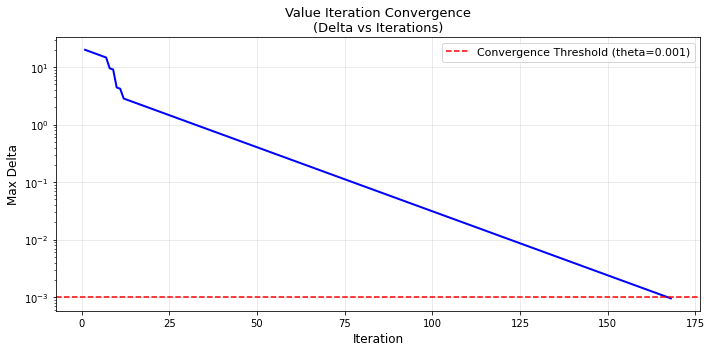

Convergence plot saved as DP_Convergence.png


In [9]:
# ============================================================
# CONVERGENCE PLOT
# Shows how delta decreases over iterations
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(delta_history) + 1), delta_history,
         color='blue', linewidth=2)
plt.axhline(y=THETA, color='red', linestyle='--',
            label=f'Convergence Threshold (theta={THETA})')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Max Delta', fontsize=12)
plt.title('Value Iteration Convergence\n(Delta vs Iterations)', fontsize=13)
plt.legend(fontsize=11)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'DP_Convergence_6x6.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Convergence plot saved as DP_Convergence.png')


## Task 4: Optimal Policy Visualization
Display the optimal policy as arrows on the grid heatmap.

- **Background color**: Value V*(s) - Green=High, Red=Low
- **Arrows**: Optimal action at each cell

Policy at Full Battery (Battery=10):


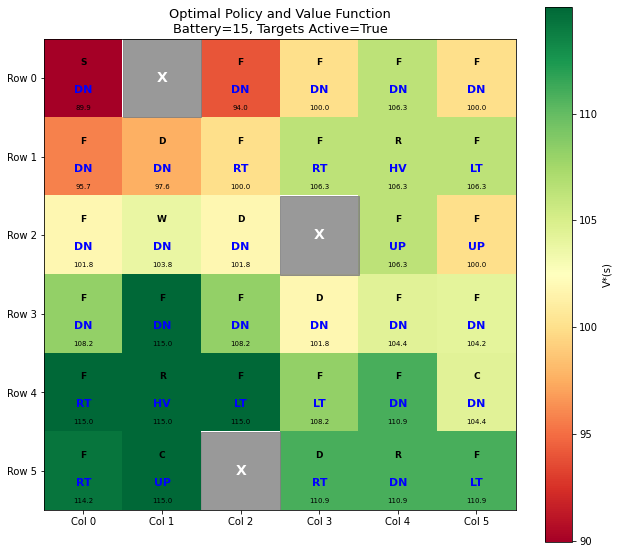

Policy plot saved as DP_Policy_Battery15_6x6.png


In [10]:
# ============================================================
# POLICY VISUALIZATION
# Arrow map overlaid on value function heatmap
# ============================================================

def visualize_policy(V, policy, battery_level, all_rescued=False):
    arrow_symbols = {
        'UP': 'up', 'DOWN': 'down',
        'LEFT': 'left', 'RIGHT': 'right', 'HOVER': 'o'
    }
    arrow_text = {
        'UP': '↑', 'DOWN': '↓',
        'LEFT': '←', 'RIGHT': '→', 'HOVER': '●'
    }

    t_status   = tuple([not all_rescued] * NUM_TARGETS)
    value_grid = np.full((GRID_SIZE, GRID_SIZE), np.nan)

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if (r, c) not in BLOCK_LOCS:
                s = (r, c, battery_level) + t_status
                if s in V:
                    value_grid[r][c] = V[s]

    fig, ax = plt.subplots(figsize=(9, 8))
    masked = np.ma.masked_invalid(value_grid)
    im = ax.imshow(masked, cmap='RdYlGn', aspect='equal')
    plt.colorbar(im, ax=ax, label='V*(s)')

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            cell_type = grid_display[r][c]

            if (r, c) in BLOCK_LOCS:
                ax.add_patch(plt.Rectangle(
                    (c - 0.5, r - 0.5), 1, 1,
                    color='gray', alpha=0.8))
                ax.text(c, r, 'X', ha='center', va='center',
                        fontsize=14, color='white', fontweight='bold')
                continue

            s = (r, c, battery_level) + t_status
            val_str = f'{value_grid[r][c]:.1f}' if not np.isnan(value_grid[r][c]) else ''
            act_str = arrow_text.get(policy.get(s, 'HOVER'), 'HV')

            ax.text(c, r - 0.2, cell_type,
                    ha='center', va='center',
                    fontsize=9, color='black', fontweight='bold')
            ax.text(c, r + 0.15, act_str,
                    ha='center', va='center',
                    fontsize=11, color='blue', fontweight='bold')
            ax.text(c, r + 0.38, val_str,
                    ha='center', va='center',
                    fontsize=7, color='black')

    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.set_xticklabels([f'Col {i}' for i in range(GRID_SIZE)])
    ax.set_yticklabels([f'Row {i}' for i in range(GRID_SIZE)])
    title = (f'Optimal Policy and Value Function\n'
             f'Battery={battery_level}, '
             f'Targets Active={not all_rescued}')
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    fname = f'DP_Policy_Battery{battery_level}_6x6.png'
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Policy plot saved as {fname}')

# Visualize at full battery
print('Policy at Full Battery (Battery=10):')
visualize_policy(V, policy, battery_level=MAX_BATTERY)


## Task 4: Low Battery Policy Visualization
Compare how the policy changes when battery is low.
The drone should prioritize the charging station over rescue targets.

Policy at Low Battery (Battery=3):


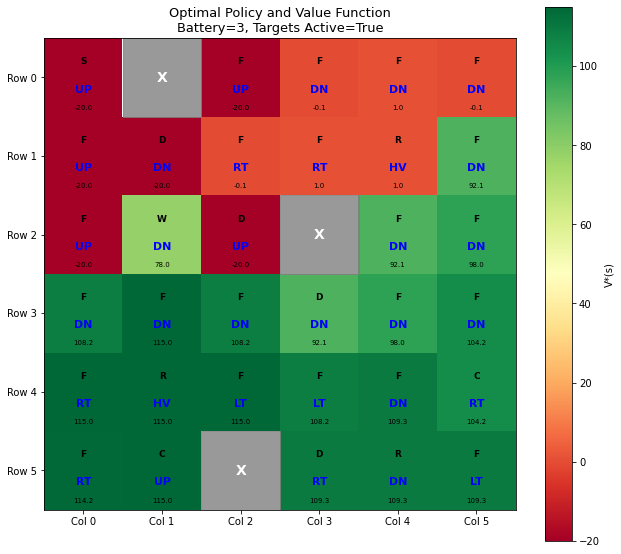

Policy plot saved as DP_Policy_Battery3_6x6.png


In [11]:
# Visualize at low battery to show behavior change
print('Policy at Low Battery (Battery=3):')
visualize_policy(V, policy, battery_level=3)


## Task 4: State-Value Heatmap Analysis
Show how V*(s) varies across grid positions for different battery levels.

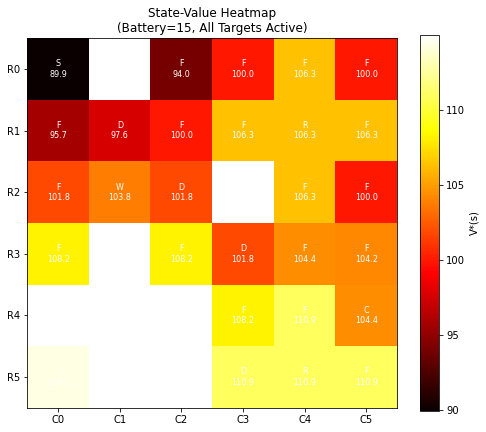

Value heatmap saved as DP_ValueHeatmap_Battery15_6x6.png


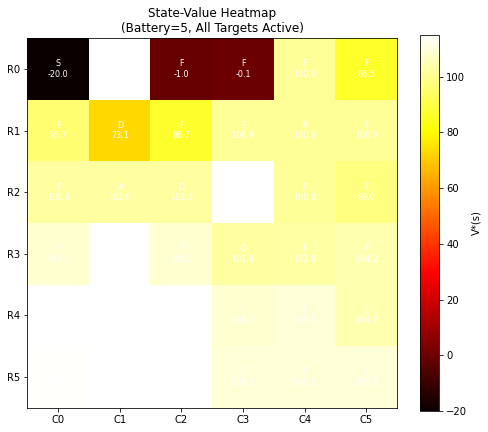

Value heatmap saved as DP_ValueHeatmap_Battery5_6x6.png


In [12]:
# ============================================================
# STATE VALUE HEATMAP
# Shows value function across grid for fixed battery level
# ============================================================

def plot_value_heatmap(V, battery_level):
    t_status   = tuple([True] * NUM_TARGETS)
    value_grid = np.full((GRID_SIZE, GRID_SIZE), np.nan)

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if (r, c) not in BLOCK_LOCS:
                s = (r, c, battery_level) + t_status
                if s in V:
                    value_grid[r][c] = V[s]

    plt.figure(figsize=(7, 6))
    masked = np.ma.masked_invalid(value_grid)
    plt.imshow(masked, cmap='hot', aspect='equal')
    plt.colorbar(label='V*(s)')

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            label = grid_display[r][c]
            if not np.isnan(value_grid[r][c]):
                plt.text(c, r,
                         f'{label}\n{value_grid[r][c]:.1f}',
                         ha='center', va='center',
                         fontsize=8, color='white')
            else:
                plt.text(c, r, label,
                         ha='center', va='center',
                         fontsize=10, color='white')

    plt.title(f'State-Value Heatmap\n(Battery={battery_level}, All Targets Active)')
    plt.xticks(range(GRID_SIZE), [f'C{i}' for i in range(GRID_SIZE)])
    plt.yticks(range(GRID_SIZE), [f'R{i}' for i in range(GRID_SIZE)])
    plt.tight_layout()
    fname = f'DP_ValueHeatmap_Battery{battery_level}_6x6.png'
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Value heatmap saved as {fname}')

plot_value_heatmap(V, battery_level=MAX_BATTERY)
plot_value_heatmap(V, battery_level=5)
plot_value_heatmap(V, battery_level=2)


## Task 4: Simulate Optimal Policy Trajectory
Follow the optimal policy from start and print step-by-step actions.

In [13]:
# ============================================================
# SIMULATE OPTIMAL TRAJECTORY
# Follow the optimal policy from start position
# ============================================================

def simulate_optimal_trajectory(policy):
    env   = DroneRescueEnv()
    state = env.reset()

    print('Initial Grid State:')
    env.render()

    total_reward = 0
    step         = 0
    done         = False

    print('\nStep-by-Step Trajectory:')
    print('-' * 75)
    print(f'{"Step":^5} | {"From":^8} | {"Action":^7} | '
          f'{"To":^8} | {"Reward":^8} | {"Battery":^8} | {"Done":^5}')
    print('-' * 75)

    while not done and step < MAX_STEPS:
        act = policy.get(state, 'HOVER')
        from_pos = (state[0], state[1])
        next_state, reward, done = env.step(act)
        to_pos = (next_state[0], next_state[1])
        total_reward += reward
        step += 1

        marker = ''
        if reward == 20:
            marker = '<- RESCUED!'
        elif reward == 5:
            marker = '<- CHARGED!'
        elif reward == -10:
            marker = '<- DANGER!'
        elif reward == -20:
            marker = '<- BATTERY DEAD!'

        print(f'{step:^5} | {str(from_pos):^8} | {act:^7} | '
              f'{str(to_pos):^8} | {reward:^8.1f} | '
              f'{next_state[2]:^8} | {str(done):^5} {marker}')
        state = next_state

    print('-' * 75)
    print(f'Total Reward : {total_reward:.2f}')
    print(f'Total Steps  : {step}')
    print('\nFinal Grid State:')
    env.render()

simulate_optimal_trajectory(policy)


Initial Grid State:
Battery: 15/15 | Targets Remaining: 3
A X F F F F 
F D F F R F 
F W D X F F 
F F F D F F 
F R F F F C 
F C X D R F 

Step-by-Step Trajectory:
---------------------------------------------------------------------------
Step  |   From   | Action  |    To    |  Reward  | Battery  | Done 
---------------------------------------------------------------------------
  1   |  (0, 0)  |  DOWN   |  (1, 0)  |   -1.0   |    14    | False 
  2   |  (1, 0)  |  DOWN   |  (2, 0)  |   -1.0   |    13    | False 
  3   |  (2, 0)  |  DOWN   |  (3, 0)  |   -1.0   |    12    | False 
  4   |  (3, 0)  |  DOWN   |  (4, 0)  |   -1.0   |    11    | False 
  5   |  (4, 0)  |  RIGHT  |  (4, 1)  |   20.0   |    10    | False <- RESCUED!
  6   |  (4, 1)  |  DOWN   |  (5, 1)  |   5.0    |    15    | False <- CHARGED!
  7   |  (5, 1)  |  DOWN   |  (5, 1)  |   5.0    |    15    | False <- CHARGED!
  8   |  (5, 1)  |  DOWN   |  (5, 1)  |   5.0    |    15    | False <- CHARGED!
  9   |  (5, 1)  |  DO

## Task 5: Scalability Discussion
Analyze how the state space grows and why Deep RL is needed at scale.

In [14]:
# ============================================================
# TASK 5: SCALABILITY AND CURSE OF DIMENSIONALITY
# ============================================================

print('=' * 65)
print('TASK 5: SCALABILITY ANALYSIS')
print('=' * 65)

scenarios = [
    ('Current (6x6, 3T, B=15)',        6,  3, 15),
    ('5x5 grid, 2 targets, B=10',       5,  2, 10),
    ('10x10 grid, 2 targets, B=10',   10,  2, 10),
    ('10x10 grid, 5 targets, B=10',   10,  5, 10),
    ('10x10 grid, 8 targets, B=20',   10,  8, 20),
    ('20x20 grid, 10 targets, B=30',  20, 10, 30),
]

print(f'{"Scenario":<35} | {"States":>12} | {"Feasible":>10}')
print('-' * 65)

for name, grid, targets, battery in scenarios:
    cells_count = grid * grid
    states = cells_count * (battery + 1) * (2 ** targets)
    feasible = 'Yes' if states < 50000 else ('Maybe' if states < 500000 else 'No')
    print(f'{name:<35} | {states:>12,} | {feasible:>10}')

print('=' * 65)
print()
print('Why DP Fails at Scale:')
print('  1. Memory   : V(s) table for millions of states needs huge RAM')
print('  2. Compute  : Each sweep is O(|S| x |A|) per iteration')
print('  3. Model    : DP requires exact P(s|s,a) - unavailable in reality')
print('  4. Continuous: Real GPS/sensor data cannot be tabulated')
print()
print('How Deep RL Solves This:')
print('  DQN  : Neural network approximates Q(s,a) without full table')
print('  PPO  : Learns policy directly from experience (model-free)')
print('  A3C  : Parallel actors explore different trajectories')
print('  MARL : Multiple drones coordinate using shared value functions')
print()
print('Real-World Connection:')
print('  Real drones use LiDAR + Camera + GPS as continuous state.')
print('  Deep RL policies are trained in simulation (AirSim, Gazebo)')
print('  and transferred to real hardware with minimal fine-tuning.')


TASK 5: SCALABILITY ANALYSIS
Scenario                            |       States |   Feasible
-----------------------------------------------------------------
Current (5x5, 2T, B=10)             |        1,100 |        Yes
6x6 grid, 3 targets, B=15           |        4,608 |        Yes
10x10 grid, 2 targets, B=10         |        4,400 |        Yes
10x10 grid, 5 targets, B=10         |       35,200 |        Yes
10x10 grid, 8 targets, B=20         |      537,600 |         No
20x20 grid, 10 targets, B=30        |   12,697,600 |         No

Why DP Fails at Scale:
  1. Memory   : V(s) table for millions of states needs huge RAM
  2. Compute  : Each sweep is O(|S| x |A|) per iteration
  3. Model    : DP requires exact P(s|s,a) - unavailable in reality
  4. Continuous: Real GPS/sensor data cannot be tabulated

How Deep RL Solves This:
  DQN  : Neural network approximates Q(s,a) without full table
  PPO  : Learns policy directly from experience (model-free)
  A3C  : Parallel actors explore di

## Final Summary
Complete summary of Part 2 results.

In [15]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print('=' * 60)
print('ASSIGNMENT PART 2 - COMPLETE SUMMARY')
print('=' * 60)
print(f'Group Number        : {G}')
print(f'Grid Size           : {GRID_SIZE}x{GRID_SIZE}')
print(f'Max Battery         : {MAX_BATTERY}')
print(f'Wind Probability    : {WIND_PROB*100:.0f}%')
print(f'Total States        : {len(all_states)}')
print(f'VI Iterations       : {iters}')
print(f'Convergence Delta   : {delta_history[-1]:.8f}')
print()
print('Files Generated:')
print('  DP_Convergence_6x6.png          - Delta vs Iterations plot')
print(f'  DP_Policy_Battery{MAX_BATTERY}_6x6.png  - Policy at full battery')
print('  DP_Policy_Battery3_6x6.png      - Policy at low battery')
print(f'  DP_ValueHeatmap_Battery{MAX_BATTERY}_6x6.png - Value heatmap full')
print('  DP_ValueHeatmap_Battery5_6x6.png - Value heatmap mid battery')
print()
print(f'Timestamp  : {datetime.datetime.now()}')
print(f'VM Hostname: {socket.gethostname()}')
print('=' * 60)


ASSIGNMENT PART 2 - COMPLETE SUMMARY
Group Number        : 204
Grid Size           : 6x6
Max Battery         : 15
Wind Probability    : 30%
Total States        : 4224
VI Iterations       : 168
Convergence Delta   : 0.00095238

Files Generated:
  DP_Convergence_6x6.png          - Delta vs Iterations plot
  DP_Policy_Battery15_6x6.png  - Policy at full battery
  DP_Policy_Battery3_6x6.png      - Policy at low battery
  DP_ValueHeatmap_Battery15_6x6.png - Value heatmap full
  DP_ValueHeatmap_Battery5_6x6.png - Value heatmap mid battery

Timestamp  : 2026-06-06 17:40:55.686600
VM Hostname: LAPTOP-BAV1OJCU
